# Architecture

## Tokenisation + Data Loading

In [4]:
import os

from socrates_ai.data_prep import TheFarmer
from socrates_ai.model_prep import Translator

farmer = TheFarmer()
tokeniser_path = os.path.join('..', 'data', 'tokenizer.json')

translator = Translator(cleaned_books_path = farmer.clean_dir)
oracle_tokens = translator.load_tokeniser(path=tokeniser_path)

In [2]:
import torch

from socrates_ai.helpers.training_helpers import load_book_paths, split_books_train_val

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

book_paths = load_book_paths(farmer.clean_dir)
print(f"{len(book_paths)} cleaned books found")

train_ids, val_ids = split_books_train_val(book_paths, oracle_tokens)
print(f"train tokens: {len(train_ids):,}")
print(f"val tokens:   {len(val_ids):,}")

Using device: cpu
634 cleaned books found
train tokens: 56,208,830
val tokens:   7,460,394


# Model

In [5]:
import torch
from socrates_ai.model_prep import MiniTransformer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MiniTransformer(
    vocab_size=oracle_tokens.get_vocab_size(),
    d_model=256,
    n_layers=4,
    n_heads=4,
    block_size=128,
    dropout=0.05,
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {n_params:,}")


Total parameters: 7,288,320


## Training

Three pieces: a helper to measure loss without training on it (`estimate_loss`), the actual training loop (`train_model`), and a plot of how loss moved over the run.

# Training Model Class

In [6]:
from socrates_ai.training import TrainingSocrates

In [ ]:
# reuses the `model` instantiated in the sanity-check cell above -- still
# untrained at this point unless you call load_checkpoint() below
trainer = TrainingSocrates(model, train_ids, val_ids, device=device, decay_target_steps=16000)


# to actually train (see the runtime note earlier in the notebook for how
# long this takes on this hardware):
# trainer.train(max_steps=5600, eval_interval=200, eval_iters=20)
# trainer.plot_training_curves()
# print(trainer.talk(oracle_tokens, "free will is", max_new_tokens=60, temperature=0.8))

[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [36]:
# trainer.train(max_steps=18000, eval_interval=500, eval_iters=15)

In [9]:
# to resume a previous session instead of starting fresh, uncomment:
trainer.load_checkpoint()  # defaults to the most recent checkpoint

Loaded checkpoint from ../data/checkpoints/step_20500.pt (resuming from step 20500)


In [10]:
print(trainer.step)
trainer.decay_target_steps

20500


16000

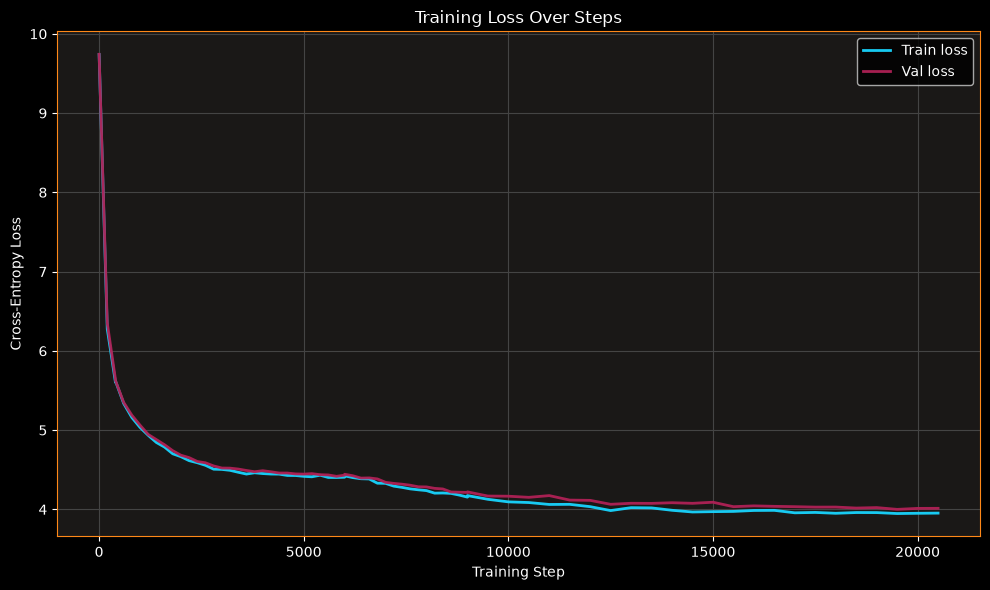

In [11]:
trainer.plot_training_curves()

In [12]:
myprompt = "The meaning of justice is"
print(trainer.talk(tokeniser=oracle_tokens, prompt=myprompt, temperature=0.7,
                   max_new_tokens=40, top_k_sampling=40))

 The meaning of justice is that of the
case of the people. I have seen that the two parties are so large as
that they are so many: they are so much of the same virtues that I can



In [19]:
top_k_vals = [20,40,70,100]
myprompt = "The meaning of virtue is"

for k in top_k_vals:
    print(trainer.talk(tokeniser=oracle_tokens, prompt=myprompt, temperature=0.8,
                   max_new_tokens=40, top_k_sampling=k))
    print("----")

 The meaning of virtue is
difficult for the nature of a given thing. The nature of a thing,
when it is the source of the whole, is also the cause of the
sensation of the thing
----
 The meaning of virtue is always the same in the
same thing, but only in the same sense, as in other words. There are
no such ideas, no real existence. But there is no such thing as

----
 The meaning of virtue is not,
though the very essence of what is called a good man.

The desire of pleasure is taken in the case
which the agent desires not to act without. But the satisfaction of
----
 The meaning of virtue is
the first of all the passions. It is true that the feelings of
love may be found; and that it is a natural science, a mental economy,
which must be sought by no
----


# Benchmarks

Model trained on 50 books, 8000 token vocan size, outputs did not make sense, no real structure, some words were formed correctly

[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
step     1 | train loss 8.7233 | val loss 8.7556
step    30 | train loss 6.9954 | val loss 7.1738
step    60 | train loss 6.5458 | val loss 6.8526
step    90 | train loss 6.3036 | val loss 6.6178
step   120 | train loss 6.0484 | val loss 6.3679
step   150 | train loss 5.8711 | val loss 6.1601
step   180 | train loss 5.7081 | val loss 6.0760
step   210 | train loss 5.6247 | val loss 5.9218
step   240 | train loss 5.5371 | val loss 5.8338
step   270 | train loss 5.4553 | val loss 5.7892
step   300 | train loss 5.4088 | val loss 5.7817

Training finished in 3693.6s